# Búsqueda de hiper-parámetros
## Framework Optuna
**Aprendizaje de Máquina - CEIA - FIUBA**

Por último, vamos a hacer una búsqueda de hiperparámetros usando [Optuna](https://optuna.org/). Como vimos en clase, Optuna es un framework que nos permite realizar búsqueda de hiperparámetros de forma más eficiente, y pensado tanto para funcionar de local con nuestra PC en una notebook, como para ser ejecutado en clusters o en la nube.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set()


In [2]:
pima_df = pd.read_csv("./datasets/pima_diabetes.csv")

# Los ceros se mantienen como 0: KNN los interpreta como señal
X = pima_df.drop("diabetes", axis=1).values
y = pima_df["diabetes"].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25,
    random_state=0, stratify=y)


Creemos la función que nos va a permitir evaluar las diferentes combinaciones de hiperparámetros en Optuna:

In [3]:
def objective(trial):
    n_neighbors = trial.suggest_int("n_neighbors", 1, 50)
    weights = trial.suggest_categorical("weights", ["uniform", "distance"])
    p = trial.suggest_float("p", 1.0, 10.0)

    model = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', KNeighborsClassifier(n_neighbors=n_neighbors, weights=weights, 
            p=p))
    ])

    score = cross_val_score(model, X_train, y_train, cv=3, scoring='f1', n_jobs=-1)
    return score.mean()


In [4]:
def champion_callback(study, frozen_trial):
    """
    Mostramos menos información, sino es demasiado verboso
    """

    winner = study.user_attrs.get("winner", None)

    if study.best_value and winner != study.best_value:
        study.set_user_attr("winner", study.best_value)
        if winner:
            improvement_percent = (abs(winner - study.best_value) / study.best_value)
            improvement_percent *= 100
            print(
                f"Trial {frozen_trial.number} achieved value: {frozen_trial.value} "
                f"with {improvement_percent: .4f}% improvement"
            )
        else:
            print(f"Initial trial {frozen_trial.number} achieved value: " 
            f"{frozen_trial.value}")

In [5]:
# Creamos un estudio de Optuna
# Optuna es un poco verboso, dejamos que solo nos muestre logs de errores
optuna.logging.set_verbosity(optuna.logging.ERROR)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=1000, callbacks=[champion_callback])

Initial trial 0 achieved value: 0.4299212760091278
Trial 1 achieved value: 0.4425244712737639 with  2.8480% improvement
Trial 2 achieved value: 0.4765062038561128 with  7.1314% improvement
Trial 4 achieved value: 0.5052715353106395 with  5.6930% improvement
Trial 14 achieved value: 0.5225727800811226 with  3.3108% improvement
Trial 19 achieved value: 0.5326771694810436 with  1.8969% improvement
Trial 20 achieved value: 0.5508818637932721 with  3.3046% improvement
Trial 21 achieved value: 0.5524074168062393 with  0.2762% improvement
Trial 22 achieved value: 0.556089790288584 with  0.6622% improvement
Trial 23 achieved value: 0.5610280618935222 with  0.8802% improvement
Trial 35 achieved value: 0.5666954270923209 with  1.0001% improvement
Trial 41 achieved value: 0.5847817759582465 with  3.0928% improvement
Trial 107 achieved value: 0.5936777196520647 with  1.4984% improvement
Trial 231 achieved value: 0.5978256456890462 with  0.6938% improvement


In [6]:
# Obtenemos los mejores hiper-parámetros encontrados
best_params = study.best_params
best_params

{'n_neighbors': 3, 'weights': 'uniform', 'p': 3.758948544078171}

In [7]:
best_params = study.best_params

classifier_knn_optuna = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', KNeighborsClassifier(**best_params))
])
classifier_knn_optuna.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


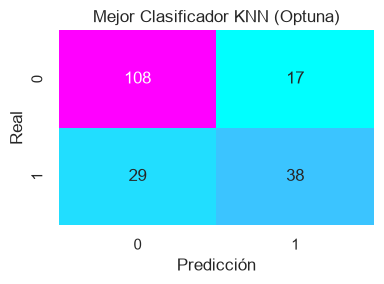

In [8]:
y_pred = classifier_knn_optuna.predict(X_test)
cm_optuna = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(cm_optuna, annot=True, fmt="d", cmap="cool", cbar=False, ax=ax)
ax.set_title("Mejor Clasificador KNN (Optuna)")
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
plt.tight_layout()
plt.show()


In [9]:
TN, FP, FN, TP = cm_optuna.ravel()

TPR = TP / (TP + FN)
TNR = TN / (TN + FP)

print("Mejor Clasificador KNN (Optuna)")
print(f"Sensibilidad (Recall): {TPR:.4f}")
print(f"Especificidad:         {TNR:.4f}")
print(f"Exactitud balanceada:  {(TPR + TNR) / 2:.4f}")
print(f"Precisión:             {precision_score(y_test, y_pred, zero_division=0):.4f}")
print(f"Recuperación (Recall): {recall_score(y_test, y_pred, zero_division=0):.4f}")
print(f"F1-score:              {f1_score(y_test, y_pred, zero_division=0):.4f}")


Mejor Clasificador KNN (Optuna)
Sensibilidad (Recall): 0.5672
Especificidad:         0.8640
Exactitud balanceada:  0.7156
Precisión:             0.6909
Recuperación (Recall): 0.5672
F1-score:              0.6230


---
Este resultado puede variar con cada ejecución. Para este modelo en particular, dado los pocos hiper-parámetros, es mejor usar la búsqueda por grilla directamente, pero en modelos más grandes (Deep Learning, o en ensambles), el rol de aplicar Optuna toma más importancia. Principalmente porque lo podemos llevar a clusters o a la nube para hacer búsquedas más poderosas.

---
## Comparativa final

Comparamos el mejor modelo encontrado por Optuna contra el **baseline heurístico** de umbral de glucosa (el predictor más discriminativo según el EDA).

In [10]:
from sklearn.metrics import balanced_accuracy_score

# Baseline: umbral de glucosa
glucosa_sin_diabetes = pima_df.loc[pima_df["diabetes"] == 0, "glucosa"]
glucosa_con_diabetes = pima_df.loc[pima_df["diabetes"] == 1, "glucosa"]
umbral_glucosa = (glucosa_sin_diabetes.median() + glucosa_con_diabetes.median()) / 2

print(f"Mediana glucosa — sin diabetes: {glucosa_sin_diabetes.median():.1f} mg/dL")
print(f"Mediana glucosa — con diabetes: {glucosa_con_diabetes.median():.1f} mg/dL")
print(f"Umbral elegido:                 {umbral_glucosa:.1f} mg/dL")

y_pred_baseline = (X_test[:, 1] > umbral_glucosa).astype(int)


Mediana glucosa — sin diabetes: 107.0 mg/dL
Mediana glucosa — con diabetes: 140.0 mg/dL
Umbral elegido:                 123.5 mg/dL


In [11]:
modelos = ["Baseline (umbral glucosa)", "KNN (Optuna)"]
preds   = [y_pred_baseline, y_pred]

df_cmp = pd.DataFrame({
    "F1-score": [f1_score(y_test, yp, zero_division=0) for yp in preds],
    "Exactitud balanceada": [balanced_accuracy_score(y_test, yp) for yp in preds],
    "Precisión": [precision_score(y_test, yp, zero_division=0) for yp in preds],
    "Sensibilidad": [recall_score(y_test, yp, zero_division=0) for yp in preds],
}, index=pd.Index(modelos))

df_cmp.round(4)


,F1-score,Exactitud balanceada,Precisión,Sensibilidad
Baseline (umbral glucosa),0.6533,0.7297,0.5904,0.7313
KNN (Optuna),0.6230,0.7156,0.6909,0.5672


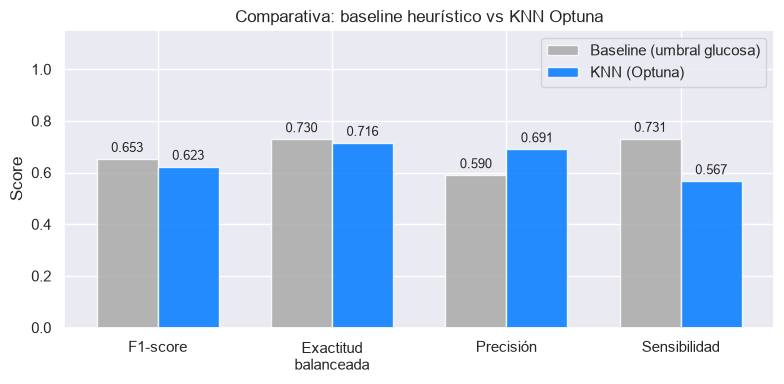

In [12]:
colores = ["#aaaaaa", "#007aff"]
metric_labels = ["F1-score", "Exactitud\nbalanceada", "Precisión", "Sensibilidad"]
x = np.arange(len(metric_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 4))
for i, (modelo, color) in enumerate(zip(modelos, colores)):
    bars = ax.bar(
        x + (i - 0.5) * width,
        df_cmp.iloc[i],
        width,
        label=modelo.replace("\n", " "),
        color=color,
        alpha=0.85,
    )
    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)

ax.set_ylim(0, 1.15)
ax.set_xticks(x)
ax.set_xticklabels(metric_labels)
ax.set_ylabel("Score")
ax.set_title("Comparativa: baseline heurístico vs KNN Optuna")
ax.legend()
plt.tight_layout()
plt.show()
